# scoring ilir and screening PSSMs

Test sets: 7mers
- screening - [FWY]xx[LVI]
- screening - [FWY]xx[FWY]
- lir central - (not the augmented set)


PSSM foregrounds:
- ilir
- screening data:
    - different z-score ranges

PSSM background:
- proteome

psuedocounts:
- 0 or 1.0

In [4]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import pssm_scoring_analysis
from lir_proteome_screen_pssm import environment as env
from lir_proteome_screen_pssm import pssms
import pandas as pd
import numpy as np
import logomaker as lm
import matplotlib.pyplot as plt
from localcider.sequenceParameters import SequenceParameters

plt.style.use("custom_standard")
plt.style.use("custom_small")
import seaborn as sns
import lir_proteome_screen_pssm.sequence_utils as seqtools
import copy
import re
# import umap
# from sklearn.preprocessing import OneHotEncoder
import lir_proteome_screen_pssm.data_loaders as dl
import lir_proteome_screen_pssm.stats as stats
plt.rcParams.update({"font.size": 14})

version = "v3"
PROCESSED_SEQUENCE_TABLES = dl.get_processed_sequence_tables(version=version)
BGFREQS = dl.get_background_frequencies(version=version)
TEST_SETS = dl.get_test_sets(version=version)
OUTPUT_DIR = Path("./01-02-plots")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
PLOT_COUNT=1

def save_plot(name: str | None = None):
    if name is None:
        name = "plot"
    global PLOT_COUNT
    global OUTPUT_DIR
    plt.savefig(OUTPUT_DIR / f"12-{PLOT_COUNT}-{name}.png", dpi=300, bbox_inches="tight")
    PLOT_COUNT += 1
    plt.close()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
pssm_scoring_analysis.check_tables(PROCESSED_SEQUENCE_TABLES, TEST_SETS)

In [4]:
auc_roc_replicates = []
seed = 55
for i in range(100):
    r = pssm_scoring_analysis.PssmTestScores(*pssm_scoring_analysis.driver(
        processed_sequence_tables=PROCESSED_SEQUENCE_TABLES,
        test_sets=TEST_SETS,
        background=BGFREQS.proteome,
        pseudo_count=0,
        z_score_ranges = [
            [1.7, 4.2],
            [1.7, 2.3],
            [2.3, 4.2],
        ],
        old_regex_test_size=50,
        new_regex_test_size=25,
        random_seed=seed,
    ))
    seed += 1
    auc_roc_replicates.append(r.auc_results)
auc_roc_replicates_df = pd.concat(auc_roc_replicates, ignore_index=True)

In [ ]:
pssm_scoring_analysis.plot_auc_results_replicates(
    auc_roc_replicates_df,
    order = [
        "screen",
        "screen: 1.7 <= z-score < 2.3",
        "screen: 2.3 <= z-score < 4.2",
        "screen: xxx[FWY]xx[WFY]",
        "screen: xxx[FWY]xx[LVI]",
        "ilir",
        # "screen: (cheating)",
        # "screen: xxx[FWY]xx[WFY] (cheating)",
    ]
)
save_plot()

# what about test sets at different z-score ranges?

In [5]:
auc_roc_replicates = []
seed = 55
for i in range(100):
    r = pssm_scoring_analysis.PssmTestScores(*pssm_scoring_analysis.driver2(
        processed_sequence_tables=PROCESSED_SEQUENCE_TABLES,
        test_sets=TEST_SETS,
        background=BGFREQS.proteome,
        pseudo_count=0,
        z_score_ranges = [
            [1.7, 4.2],
            [1.7, 2.3],
            [2.3, 4.2],
        ],
        test_size=40,
        random_seed=seed,
    ))
    seed += 1
    auc_roc_replicates.append(r.auc_results)
auc_roc_replicates_df = pd.concat(auc_roc_replicates, ignore_index=True)

154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creation
154 of 314 training sequences left after test set creati

In [ ]:
for i in auc_roc_replicates_df["test set"].unique(): print(i)
for i in auc_roc_replicates_df["foreground"].unique(): print(i)

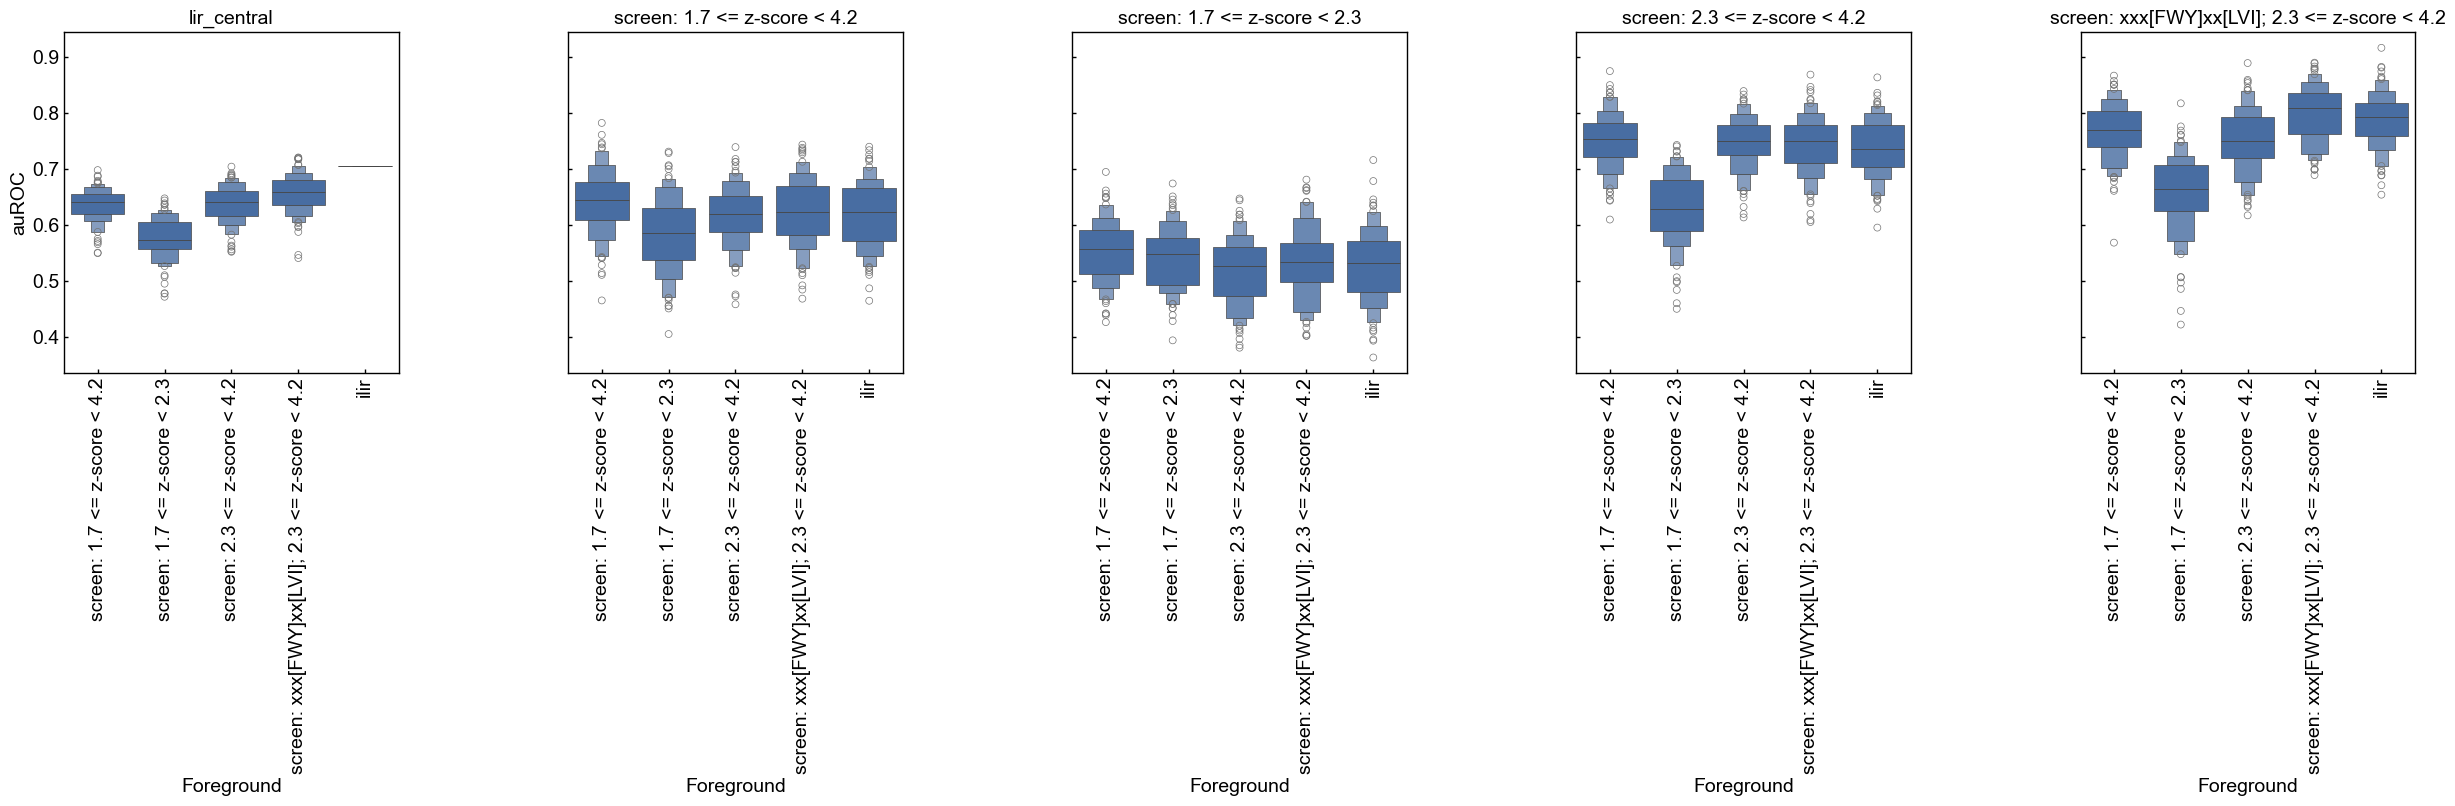

In [ ]:
plt.rcParams.update({"font.size": 14})
pssm_scoring_analysis.plot_auc_results_replicates(
    auc_roc_replicates_df,
    order=[
        "screen: 1.7 <= z-score < 4.2",
        "screen: 1.7 <= z-score < 2.3",
        "screen: 2.3 <= z-score < 4.2",
        "screen: xxx[FWY]xx[LVI]; 2.3 <= z-score < 4.2",
        "ilir",
    ]
)
save_plot()

findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: Font family 'Bitstream Vera Sans' not found.
findfont: 

0.11111111111111109
0.9999999999999996


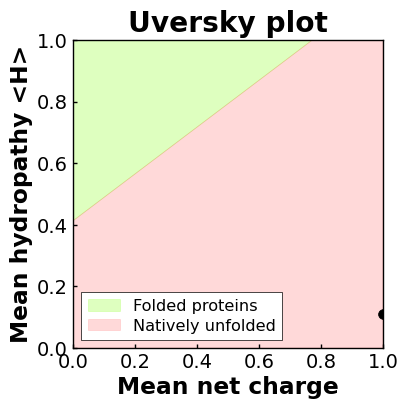

In [10]:
Seqob = SequenceParameters('EEEEEEEEEEEEEEEEEEEEEEEEEE')
print(Seqob.get_uversky_hydropathy())
print(Seqob.get_mean_hydropathy())
Seqob.show_uverskyPlot()
# Seqob.show_linearHydropathy()